<a href="https://colab.research.google.com/github/nannastahl/CB2330-project/blob/main/F%C3%B6rslag_kod_number_of_contacts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

theta = 0.8571428571428571
Expected contacts: 36.0


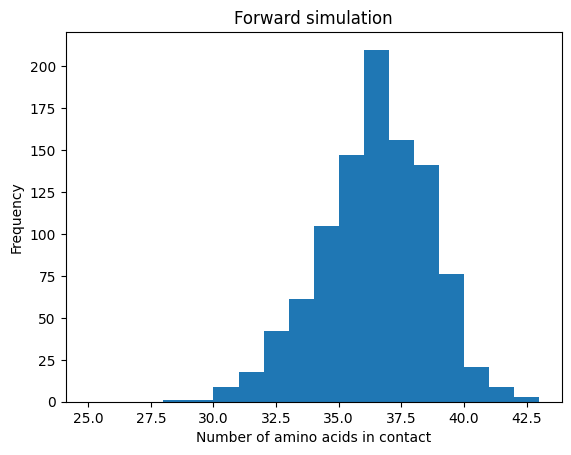

True theta: 0.7
Simulated observation: 28
Acceptance rate: 0.25605


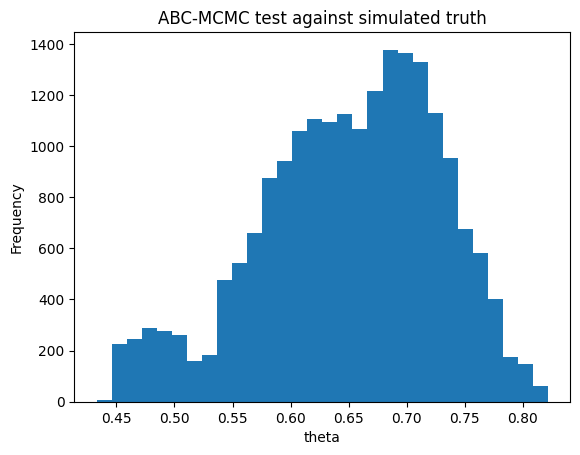

Observed contacts: 36
Acceptance rate: 0.33185


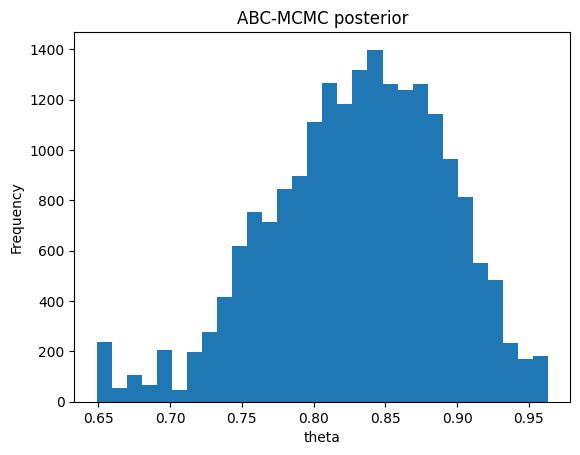

In [5]:
import numpy as np
import matplotlib.pyplot as plt

N = 42
x_obs = 36 #36/42 amino acids in contact with DOPS membrane at pH 7

A_LCG = 1664525
C_LCG = 1013904223
M_LCG = 2 ** 32

seed = 30


def lcg(state, a, c, m):
    """The next state of a linear congruential generator: s_{i+1} = (a * s_i + c) mod m."""
    return (a * state + c) % m


def simulation(theta, state, n_residues=N):
    contacts = 0
    for i in range(n_residues):
        state = lcg(state, A_LCG, C_LCG, M_LCG)
        rs = state / M_LCG #Random number between 0 and 1
        if rs < theta: #Amino acid is in contact with membrane
            contacts += 1
    return contacts, state


#Forward simulation

theta = 36/42 # Based on the contacts observed in experiment, maybe try different thetas?
n_simulations = 1000
simulated_contacts = [0] * n_simulations

state = seed

for i in range(n_simulations):
    simulated_contacts[i], state = simulation(theta, state)

print("theta =", theta)
print("Expected contacts:", N * theta)

plt.hist(simulated_contacts, bins=range(25, 44)) #AI helped with binning
plt.xlabel("Number of amino acids in contact")
plt.ylabel("Frequency")
plt.title("Forward simulation")
plt.show()

PRIOR = (0.0, 1.0)


def abc_mcmc(n_steps, epsilon, start, state, x_obs, half_width=0.03):
    theta = start
    chain = [0.0] * n_steps
    n_acc = 0
    for t in range(n_steps):
        state = lcg(state, A_LCG, C_LCG, M_LCG)
        prop = theta + half_width * (2 * state / M_LCG - 1) #Proposed theta
        if PRIOR[0] <= prop <= PRIOR[1]:                    #Only use theta values inside prior
            x_sim, state = simulation(prop, state)
            #Accept if simulated number of contacts is close enough to observed.
            if abs(x_sim - x_obs) <= epsilon:
                theta = prop
                n_acc += 1
        chain[t] = theta

    return chain, n_acc, state

#Test against simulated truth
True_Theta= 0.7

state = seed
x_test, state = simulation(True_Theta, state)

print("True theta:", True_Theta)
print("Simulated observation:", x_test)

chain_test, n_acc_test, state = abc_mcmc(n_steps=20000, epsilon=1, start=0.8, state=state, x_obs=x_test)
posterior_test = chain_test

print("Acceptance rate:", n_acc_test / len(chain_test)) #Ad standard deviation?

plt.hist(posterior_test, bins=30)
plt.xlabel("theta")
plt.ylabel("Frequency")
plt.title("ABC-MCMC test against simulated truth")
plt.show()



#Estimate theta from paper result

state = seed

chain, n_acc, state = abc_mcmc(n_steps=20000, epsilon=1,start=0.8,state=state, x_obs=x_obs)
posterior = chain

print("Observed contacts:", x_obs)
print("Acceptance rate:", n_acc / len(chain))


plt.hist(posterior, bins=30)
plt.xlabel("theta")
plt.ylabel("Frequency")
plt.title("ABC-MCMC posterior")
plt.show()


#Assumptions:
#Each amino acid is either in contact or not in contact with the membrane.
#Each amino acid has the same probability theta of being in contact.
#Contacts between amino acids are independent.
#The observed 36 contacts are treated as one observation from this process.
#Residue identity, charge and position are not included in the model.